# Zadania Lista 2

**Wymagania**

- Jupyter'a  należy uruchomić korzystając ze środowiska w kontenerze Docker, w przeciwnym razie przyznane będzie 80% zdobytych punktów. (To wymaganie zostanie z nami do końca kursu, zgodnie z przedstawionymi zasadami.)

#### 1. (5 pkt) Wykonaj podzadania zdefiniowane w punktach a), b) i c) z wykorzystaniem bibliotek `numpy` i `matplotlib`

a) **(2.5 pkt)** Poniżej przedstawiono implementację funkcji `calculate`, w której zrealizowano zbiór operacji na dwóch dwuwymiarowych macierzach $a$ i $b$. Zmień implementację tej funkcji tak, aby pozbyć się wykorzystania pętli - w tym celu wykorzystaj operacje zdefiniowane w bibliotece `numpy`. Zweryfikuj poprawność nowo zdefiowanej funkcji dla dowolnie wybranego zestawu parametrów

```python
def calculate(
    a: np.ndarray, 
    b: np.ndarray,
    threshold: int = 5
) -> float:
'''Implements bunch of operations on matrices.'''
    # Check a and b dimensions
    assert a.shape == b.shape
    # Check whether array is 2D 
    assert len(a.shape) == 2

    rows = a.shape[0]
    cols = a.shape[1]
    b_sum = 0
    out = 0.0
    c = np.zeros(a.shape)

    for row_id in range(rows):
        for col_id in range(cols):
            if a[row_id][col_id] > threshold:
                c[row_id][col_id] = abs(
                    a[row_id][col_id] - b[row_id][col_id]
                )
            else:
                c[row_id][col_id] = 1

            b_sum += b[row_id][col_id]


    row_avgs = []
    for row_id in range(rows):
        row_sum = 0
        for col_id in range(cols):
            row_sum += c[row_id][col_id]

        row_avg = row_sum / cols
        out += (row_avg * 100) / b_sum  

    return out
```


In [147]:
import numpy as np

In [148]:
def calculate(a: np.ndarray, b: np.ndarray, threshold: int = 5) -> float:
    """Implements bunch of operations on matrices."""
    # Check a and b dimensions
    assert a.shape == b.shape
    # Check whether array is 2D
    assert len(a.shape) == 2

    rows = a.shape[0]
    cols = a.shape[1]
    b_sum = 0
    out = 0.0
    c = np.zeros(a.shape)

    for row_id in range(rows):
        for col_id in range(cols):
            if a[row_id][col_id] > threshold:
                c[row_id][col_id] = abs(a[row_id][col_id] - b[row_id][col_id])
            else:
                c[row_id][col_id] = 1

            b_sum += b[row_id][col_id]

    row_avgs = []
    for row_id in range(rows):
        row_sum = 0
        for col_id in range(cols):
            row_sum += c[row_id][col_id]

        row_avg = row_sum / cols
        out += (row_avg * 100) / b_sum

    return out

In [149]:
a = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
b = np.array([[9, 8, 7], [6, 5, 4], [3, 2, 1]])

In [150]:
def calculate_numpy(a, b, theshold):

    c = np.where(a > theshold, np.abs(a - b), 1)
    b_sum = np.sum(b)
    return np.sum(np.mean(c, axis=1) * 100 / b_sum)

In [151]:
assert calculate(a, b, 5) == calculate_numpy(a, b, 5), "Results differ!"

b) **(1 pkt)** Dokonaj porównania czasów wykonania funkcji `calculate` i tej zaimplementowanej w punkcie 1. Wylosuj macierze wejściowe $a$ i $b$ z rozkładu dyskretnego jednostajnego z zakresu 0-10 oraz przyjmij wartość parametru `threshold` na 5. Obliczenia przeprowadź dla następujących wymiarów macierzy:

- 10x10
- 100x100
- 1000x1000
- 10000x10000

**Uwaga**
W celu mierzenia czasu można użyć komendy %timeit
https://ipython.readthedocs.io/en/stable/interactive/magics.html#magic-timeit


In [152]:
import time

In [153]:
def generate_random_matrix(rows, cols, low=0, high=10):
    return np.random.randint(low, high, size=(rows, cols))


def compare(a, b):
    start = time.time()
    result = calculate(a, b)
    end = time.time()
    method_one_time = end - start

    start = time.time()
    result_numpy = calculate_numpy(a, b, 5)
    end = time.time()
    method_two_time = end - start

    assert np.isclose(result, result_numpy), (
        f"Results differ: {result} vs {result_numpy}"
    )

    return method_one_time, method_two_time

In [154]:
for p in [1, 2, 3, 4]:
    size = 10**p
    print(f"comparing for size {size}x{size}")
    time_iter, time_numpy = compare(
        generate_random_matrix(size, size), generate_random_matrix(size, size)
    )
    print(f"Method 1 time: {time_iter:.4f} seconds")
    print(f"Method 2 time: {time_numpy:.4f} seconds")
    print("\n")

comparing for size 10x10
Method 1 time: 0.0001 seconds
Method 2 time: 0.0001 seconds


comparing for size 100x100
Method 1 time: 0.0071 seconds
Method 2 time: 0.0003 seconds


comparing for size 1000x1000
Method 1 time: 0.7450 seconds
Method 2 time: 0.0040 seconds


comparing for size 10000x10000
Method 1 time: 73.3923 seconds
Method 2 time: 0.6032 seconds




c) **(1.5 pkt)** Wykorzystując bibliotekę `matplotlib` narysuj wykres porównujący czas działania obu implementacji dla poszczególnych rozmiarów macierzy. Dobierz odpowiedni typ wykresu, podpisz etykiety osi i uzupełnij tytuł wykresu.

In [155]:
import matplotlib.pyplot as plt

In [156]:
results = {}

for p in [1, 2, 3, 4]:
    size = 10**p
    time1, time2 = compare(
        generate_random_matrix(size, size), generate_random_matrix(size, size)
    )
    results[size] = {"method_one_time": time1, "method_two_time": time2}

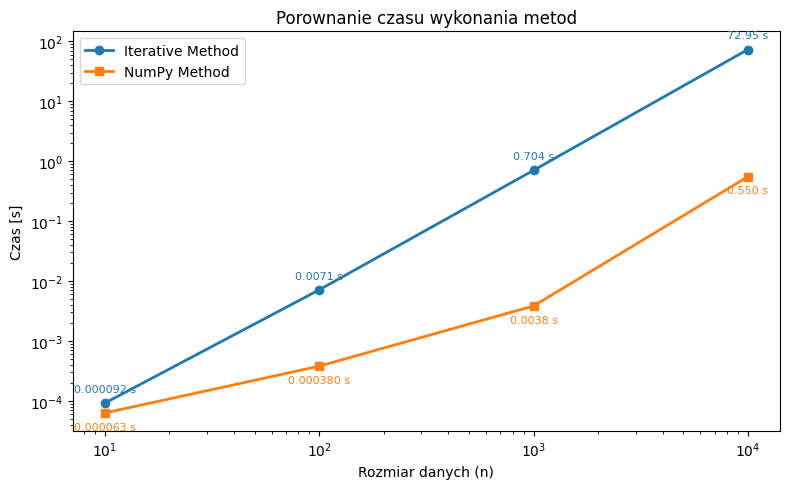

In [191]:
sizes = sorted(results.keys())
method_one = [results[n]["method_one_time"] for n in sizes]
method_two = [results[n]["method_two_time"] for n in sizes]

plt.figure(figsize=(8, 5))
line1, = plt.plot(
    sizes, method_one, marker="o", linewidth=2, label="Iterative Method"
 )
line2, = plt.plot(
    sizes, method_two, marker="s", linewidth=2, label="NumPy Method"
 )

def format_seconds(value):
    if value >= 1:
        return f"{value:.2f} s"
    if value >= 0.01:
        return f"{value:.3f} s"
    if value >= 0.001:
        return f"{value:.4f} s"
    return f"{value:.6f} s"

for x, y in zip(sizes, method_one):
    plt.annotate(
        format_seconds(y),
        (x, y),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        color=line1.get_color(),
        fontsize=8,
    )

for x, y in zip(sizes, method_two):
    plt.annotate(
        format_seconds(y),
        (x, y),
        textcoords="offset points",
        xytext=(0, -12),
        ha="center",
        color=line2.get_color(),
        fontsize=8,
    )

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Rozmiar danych (n)")
plt.ylabel("Czas [s]")
plt.title("Porownanie czasu wykonania metod")
plt.legend()
plt.tight_layout()
plt.show()

#### 2. (5 pkt) Wykonaj podzadania zdefiniowane w punktach a), b), c) i d) z wykorzystaniem bibliotek `pandas`, `matplotlib`.

a) **(0.25 pkt)** Pobierz zbiór danych [boston house prices](https://lib.stat.cmu.edu/datasets/boston) i wczytaj go do postaci `DataFrame` z biblioteki `pandas`. Dodatkowo wyświetl 20 pierwszych rekordów.

In [193]:
data_url = "http://lib.stat.cmu.edu/datasets/boston"

columns = [
    "CRIM",
    "ZN",
    "INDUS",
    "CHAS",
    "NOX",
    "RM",
    "AGE",
    "DIS",
    "RAD",
    "TAX",
    "PTRATIO",
    "B",
    "LSTAT",
    "MEDV",
]

raw_df = pd.read_csv(data_url, sep=r"\s+", skiprows=22, header=None)

values = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :3]])

df = pd.DataFrame(values, columns=columns)

In [194]:
df.head(20)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2
5,0.02985,0.0,2.18,0.0,0.458,6.430,58.7,6.0622,3.0,222.0,18.7,394.12,5.21,28.7
6,0.08829,12.5,7.87,0.0,0.524,6.012,66.6,5.5605,5.0,311.0,15.2,395.60,12.43,22.9
7,0.14455,12.5,7.87,0.0,0.524,6.172,96.1,5.9505,5.0,311.0,15.2,396.90,19.15,27.1
8,0.21124,12.5,7.87,0.0,0.524,5.631,100.0,6.0821,5.0,311.0,15.2,386.63,29.93,16.5
9,0.17004,12.5,7.87,0.0,0.524,6.004,85.9,6.5921,5.0,311.0,15.2,386.71,17.10,18.9


b) **(0.75 pkt)** Używając funkcji `apply` utwórz kolumnę 'HIGH_TAX', która sprawdza czy dla danego rekordu stawka podatkowa (kolumna 'TAX')  jest większa od mediany stawki podatkowej wszystkich rekordów



In [195]:
tax_median = df["TAX"].median()
df["HIGH_TAX"] = df.apply(lambda row: row["TAX"] > tax_median, axis=1)
df["HIGH_TAX"].value_counts()

HIGH_TAX
False    256
True     250
Name: count, dtype: int64

c) **(1.5 pkt)** Pogrupuj rekordy wg. kolumny 'HIGH_TAX' i wybierz 4 cechy ze zbioru danych w których najbardziej widać różnicę dla grup 'HIGH_TAX'



In [196]:
def calculate_z_score(df, numeric_cols):
    z = (df[numeric_cols] - df[numeric_cols].mean()) / df[numeric_cols].std(ddof=0)
    return z


def compare_groups(df, numeric_cols, group_by_col="HIGH_TAX"):
    z = calculate_z_score(df, numeric_cols)
    group_means_z = z.groupby(df[group_by_col]).mean()
    feature_diff = (
        (group_means_z.loc[True] - group_means_z.loc[False])
        .abs()
        .sort_values(ascending=False)
    )
    return feature_diff

In [197]:
numeric_cols = df.select_dtypes(include="number").columns.drop("TAX", errors="ignore")
top4_diff = compare_groups(df, numeric_cols).drop("TAX", errors="ignore").head(4)
top4_diff

INDUS    1.272780
RAD      1.205798
NOX      1.189541
DIS      0.909662
dtype: float64

d) **(2.5 pkt)** Dla wybranych cech w punkcie `c)` porównaj wartości tych cech na wykresach. Dobierz odpowiedni typ wykresu (słupkowy, kołowy, liniowy, histogram, ...). Wybór typu musi być zasadny. Wykresy mają być umiejscowione w jednym wykresie z subplotem składającym się z 2 kolumn i 2 rzędów. Wykresy powinny posiadać etykiety osi X i Y oraz legendę.
Uwaga: wykresy z jedynie dwoma punktami danych np. średnie wartości dla dwóch grup nie będą akceptowane. Do takich danych służą tabele.


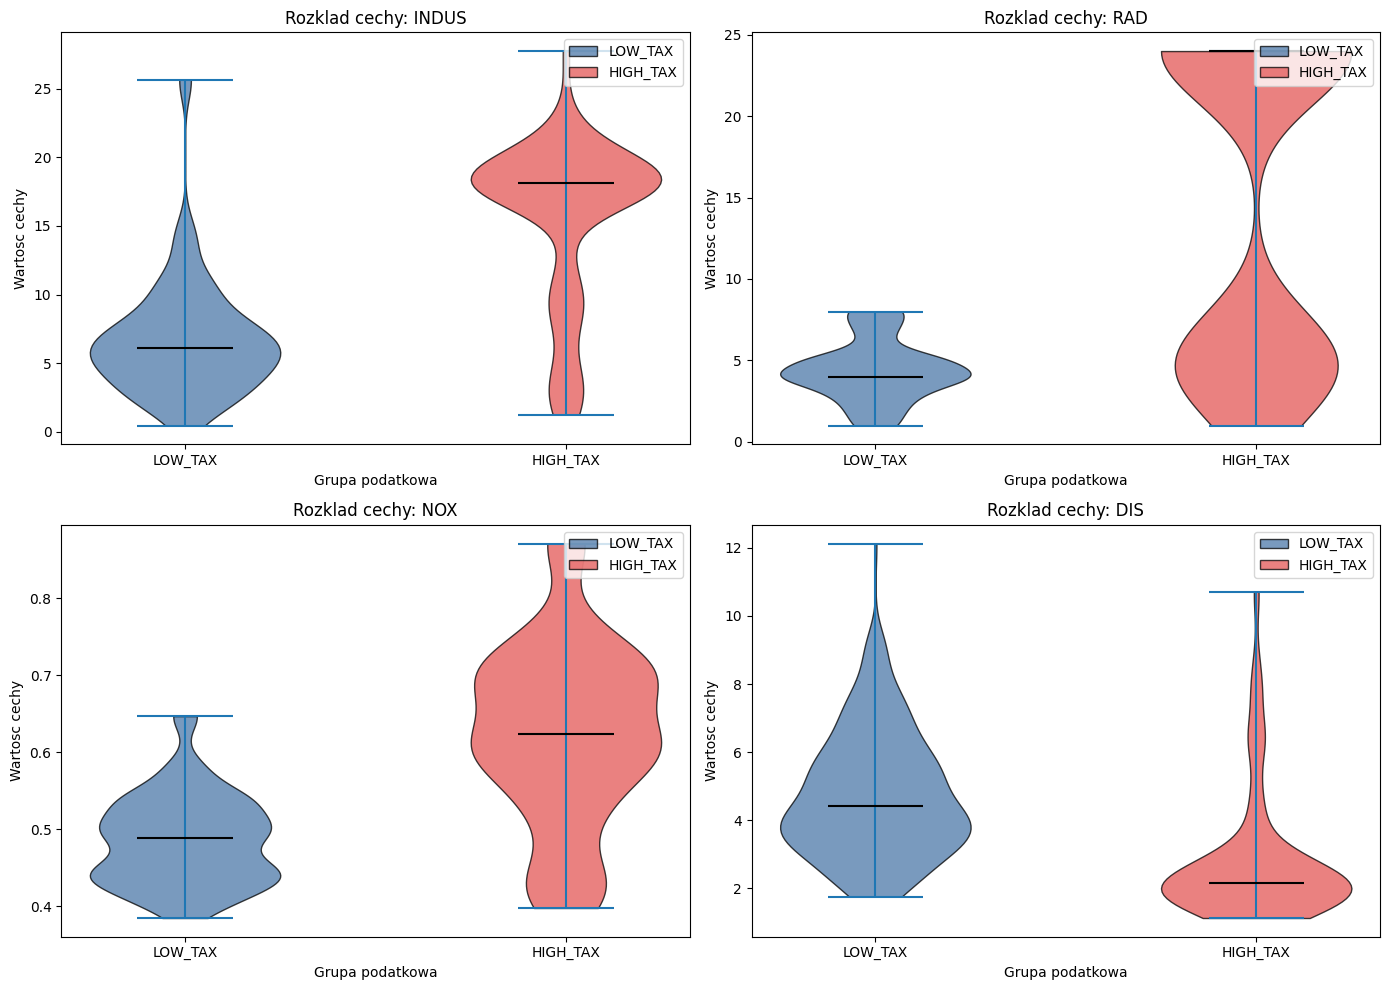

In [198]:
from matplotlib.patches import Patch

selected_features = top4_diff.index
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

low_color = "#4C78A8"
high_color = "#E45756"

for ax, feature in zip(axes.flatten(), selected_features):
    data_low = df[~df["HIGH_TAX"]][feature].dropna()
    data_high = df[df["HIGH_TAX"]][feature].dropna()
    parts = ax.violinplot([data_low, data_high], showmedians=True)

    for body, color in zip(parts["bodies"], [low_color, high_color]):
        body.set_facecolor(color)
        body.set_edgecolor("black")
        body.set_alpha(0.75)

    if "cmedians" in parts:
        parts["cmedians"].set_color("black")
        parts["cmedians"].set_linewidth(1.5)

    ax.set_xticks([1, 2])
    ax.set_xticklabels(["LOW_TAX", "HIGH_TAX"])
    ax.set_title(f"Rozklad cechy: {feature}")
    ax.set_xlabel("Grupa podatkowa")
    ax.set_ylabel("Wartosc cechy")

    legend_handles = [
        Patch(facecolor=low_color, edgecolor="black", alpha=0.75, label="LOW_TAX"),
        Patch(facecolor=high_color, edgecolor="black", alpha=0.75, label="HIGH_TAX"),
    ]
    ax.legend(handles=legend_handles, loc="upper right")

plt.tight_layout()
plt.show()

#### [OPCJONALNE] 3. (1 pkt) Zapoznaj się z biblioteką [polars](https://docs.pola.rs/) i wykonaj polecenia 2 a) b) c) korzystając z tej biblioteki 

In [199]:
import polars as pl

#### a)

In [200]:
boston = fetch_openml(name="boston", version=1, as_frame=True, parser="auto")

df = pl.DataFrame({col: boston.frame[col].to_numpy() for col in boston.frame.columns})
df.head(20)

CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
f64,f64,f64,str,f64,f64,f64,f64,str,f64,f64,f64,f64,f64
0.00632,18.0,2.31,"""0""",0.538,6.575,65.2,4.09,"""1""",296.0,15.3,396.9,4.98,24.0
0.02731,0.0,7.07,"""0""",0.469,6.421,78.9,4.9671,"""2""",242.0,17.8,396.9,9.14,21.6
0.02729,0.0,7.07,"""0""",0.469,7.185,61.1,4.9671,"""2""",242.0,17.8,392.83,4.03,34.7
0.03237,0.0,2.18,"""0""",0.458,6.998,45.8,6.0622,"""3""",222.0,18.7,394.63,2.94,33.4
0.06905,0.0,2.18,"""0""",0.458,7.147,54.2,6.0622,"""3""",222.0,18.7,396.9,5.33,36.2
…,…,…,…,…,…,…,…,…,…,…,…,…,…
0.62739,0.0,8.14,"""0""",0.538,5.834,56.5,4.4986,"""4""",307.0,21.0,395.62,8.47,19.9
1.05393,0.0,8.14,"""0""",0.538,5.935,29.3,4.4986,"""4""",307.0,21.0,386.85,6.58,23.1
0.7842,0.0,8.14,"""0""",0.538,5.99,81.7,4.2579,"""4""",307.0,21.0,386.75,14.67,17.5


### b)

In [201]:
tax_median = df.select(pl.col("TAX").median()).item()
df = df.with_columns((pl.col("TAX") > tax_median).alias("HIGH_TAX"))
df["HIGH_TAX"].value_counts()

HIGH_TAX,count
bool,u32
false,256
true,250


#### c)

In [202]:
def calculate_z_score(df: pl.DataFrame, numeric_cols: list[str]) -> pl.DataFrame:
    return df.with_columns(
        (pl.col(numeric_cols) - pl.col(numeric_cols).mean())
        / pl.col(numeric_cols).std(ddof=0)
    )


def compare_groups(
    df: pl.DataFrame, numeric_cols: list[str], group_by_col: str = "HIGH_TAX"
) -> pl.DataFrame:
    df_z = calculate_z_score(df, numeric_cols)

    group_means = df_z.group_by(group_by_col).mean().sort(group_by_col, descending=True)

    feature_diff = group_means.select(
        (pl.col(numeric_cols).first() - pl.col(numeric_cols).last()).abs()
    )

    return feature_diff

In [203]:
numeric_cols = [s.name for s in df if s.dtype.is_numeric()]
numeric_cols.remove("TAX")
res = compare_groups_polars(df, numeric_cols)

In [204]:
result = res.unpivot(variable_name="Feature", value_name="Difference").sort(
    "Difference", descending=True
)
result.head(4)

Feature,Difference
str,f64
"""INDUS""",1.27278
"""NOX""",1.189541
"""DIS""",0.909662
"""LSTAT""",0.853656


#### [OPCJONALNE] 4. (1 pkt) Zapoznaj się z biblioteką [seaborn](https://seaborn.pydata.org/index.html) i zmień wykresy z punktu 2 d) na używające tej biblioteki

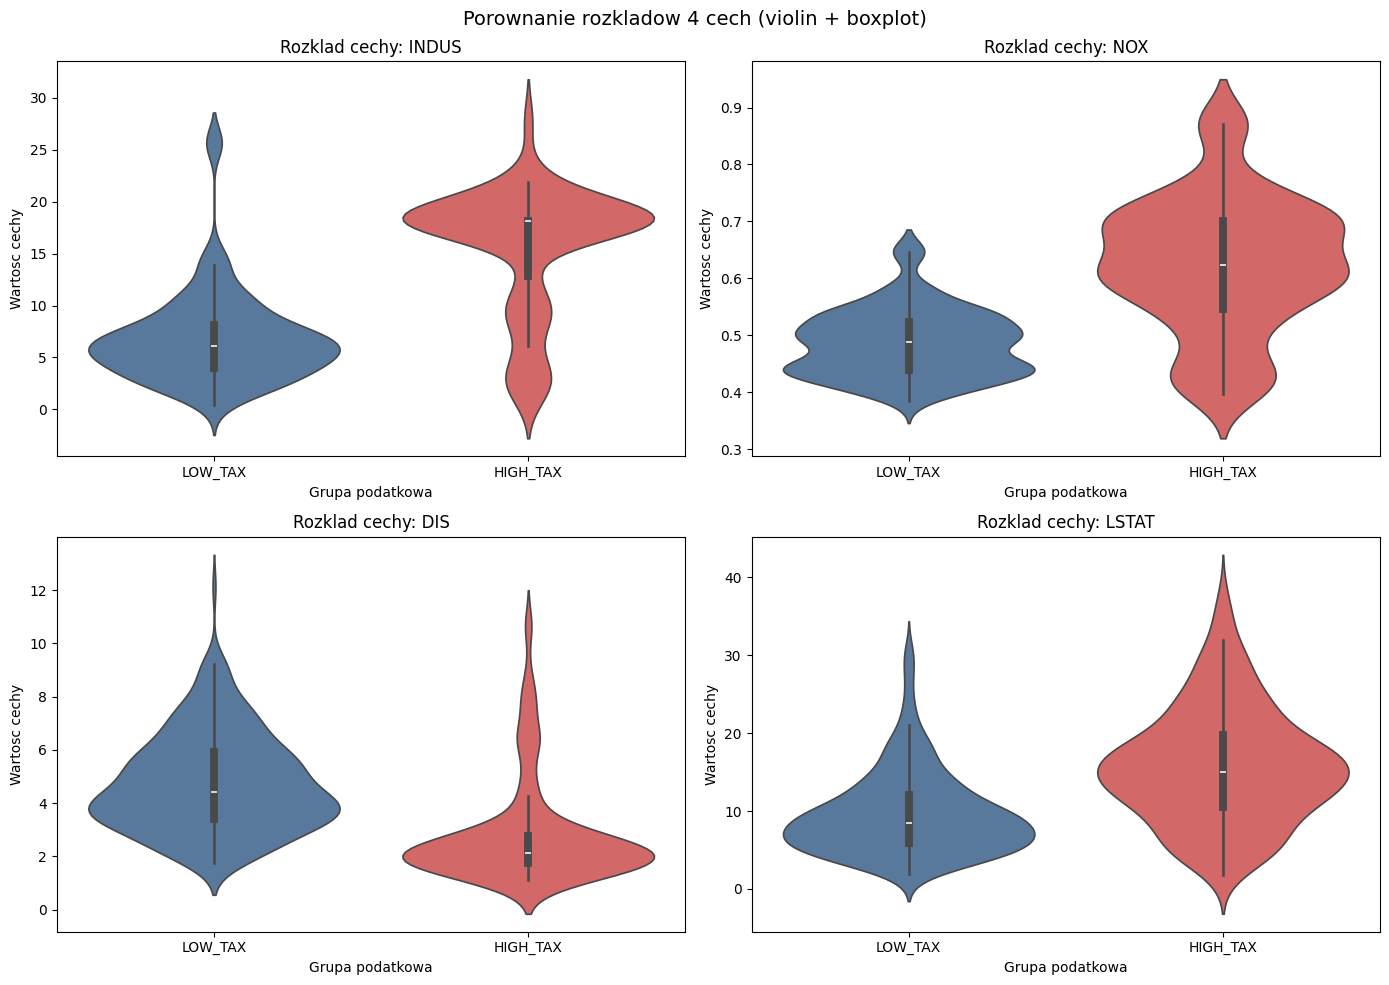

In [205]:
selected_features = list(result["Feature"][:4])
plot_df = pd.DataFrame(df.to_dict(as_series=False))
plot_df["HIGH_TAX_LABEL"] = plot_df["HIGH_TAX"].map(
    {False: "LOW_TAX", True: "HIGH_TAX"}
)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, feature in zip(axes, selected_features):
    sns.violinplot(
        data=plot_df,
        x="HIGH_TAX_LABEL",
        y=feature,
        hue="HIGH_TAX_LABEL",
        inner="box",
        palette={"LOW_TAX": "#4C78A8", "HIGH_TAX": "#E45756"},
        legend=False,
        ax=ax,
    )
    ax.set_title(f"Rozklad cechy: {feature}")
    ax.set_xlabel("Grupa podatkowa")
    ax.set_ylabel("Wartosc cechy")

fig.suptitle("Porownanie rozkladow 4 cech (violin + boxplot)", fontsize=14)
plt.tight_layout()
plt.show()